In [1]:
import sys
print(sys.executable)

c:\Users\keena\Documents\Electoral_Tribes\sklearn-env\Scripts\python.exe


In [2]:
import sys
print(sys.executable)

import sklearn
print(sklearn.__version__)

c:\Users\keena\Documents\Electoral_Tribes\sklearn-env\Scripts\python.exe
1.8.0


In [3]:
import pandas as pd
import sklearn
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

OUT_DIR = Path("../data/processed")
MODEL_DIR = Path("../data/model_outputs")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

oa = pd.read_csv(OUT_DIR / "oa_cluster_features_v1.csv", low_memory=False)

print(oa.shape)
display(oa.head())

(188880, 34)


,OA21CD,total_residents,age_15_24_pct,age_25_34_pct,age_50_64_pct,age_65_plus_pct,uk_born_pct,non_uk_born_pct,resident_10_plus_years_pct,resident_less_5_years_pct,...,full_time_student_pct,retired_pct,long_term_sick_disabled_pct,no_qualifications_pct,level_1_2_pct,apprenticeship_pct,level_4_plus_pct,one_person_household_pct,married_couple_family_pct,lone_parent_family_pct
0,E00000001,176,0.039773,0.096591,0.227273,0.380682,0.670455,0.329545,0.193182,0.113636,...,0.031056,0.322981,0.006211,0.029304,0.106250,0.006250,0.754386,0.361702,0.329787,0.053191
1,E00000003,256,0.089844,0.117188,0.203125,0.296875,0.715953,0.284047,0.167969,0.050781,...,0.089686,0.255605,0.000000,0.029304,0.057413,0.004525,0.754386,0.247706,0.394495,0.027523
2,E00000005,112,0.080357,0.125000,0.250000,0.250000,0.657658,0.342342,0.241071,0.062500,...,0.038095,0.219048,0.009524,0.029304,0.057413,0.028302,0.754386,0.412698,0.238095,0.063492
3,E00000007,144,0.118056,0.375000,0.118056,0.118056,0.408163,0.591837,0.131034,0.283111,...,0.077465,0.119718,0.007042,0.035971,0.057413,0.007194,0.754386,0.430233,0.116279,0.008065
4,E00000010,178,0.073034,0.185393,0.224719,0.117978,0.541899,0.458101,0.269663,0.089888,...,0.052941,0.088235,0.052941,0.087209,0.191860,0.000000,0.540698,0.666667,0.069737,0.008065


In [94]:
import os
path = "C:\\Users\\keena\\Documents\\Electoral_Tribes\\data\\model_outputs\\k5"
dir_list = os.listdir(path)
print(dir_list)

['k5_cluster_age_band_shares_v1.csv', 'k5_cluster_defining_features_v1.csv', 'k5_cluster_feature_means_v1.csv', 'k5_cluster_feature_medians_v1.csv', 'k5_cluster_feature_zscores_v1.csv', 'k5_cluster_profile_summaries_v1.csv', 'k5_cluster_sizes_v1.csv']


In [4]:
oa.columns.tolist()

['OA21CD',
 'total_residents',
 'age_15_24_pct',
 'age_25_34_pct',
 'age_50_64_pct',
 'age_65_plus_pct',
 'uk_born_pct',
 'non_uk_born_pct',
 'resident_10_plus_years_pct',
 'resident_less_5_years_pct',
 'white_british_pct',
 'white_other_pct',
 'non_white_pct',
 'owned_pct',
 'owns_outright_pct',
 'social_rented_pct',
 'private_rented_pct',
 'house_type_pct',
 'flat_type_pct',
 'managerial_professional_pct',
 'skilled_traditional_pct',
 'routine_service_elementary_pct',
 'employed_pct',
 'unemployed_pct',
 'full_time_student_pct',
 'retired_pct',
 'long_term_sick_disabled_pct',
 'no_qualifications_pct',
 'level_1_2_pct',
 'apprenticeship_pct',
 'level_4_plus_pct',
 'one_person_household_pct',
 'married_couple_family_pct',
 'lone_parent_family_pct']

In [5]:
id_cols = ["OA21CD", "total_residents"]
cluster_features = [c for c in oa.columns if c not in id_cols]

cluster_features

['age_15_24_pct',
 'age_25_34_pct',
 'age_50_64_pct',
 'age_65_plus_pct',
 'uk_born_pct',
 'non_uk_born_pct',
 'resident_10_plus_years_pct',
 'resident_less_5_years_pct',
 'white_british_pct',
 'white_other_pct',
 'non_white_pct',
 'owned_pct',
 'owns_outright_pct',
 'social_rented_pct',
 'private_rented_pct',
 'house_type_pct',
 'flat_type_pct',
 'managerial_professional_pct',
 'skilled_traditional_pct',
 'routine_service_elementary_pct',
 'employed_pct',
 'unemployed_pct',
 'full_time_student_pct',
 'retired_pct',
 'long_term_sick_disabled_pct',
 'no_qualifications_pct',
 'level_1_2_pct',
 'apprenticeship_pct',
 'level_4_plus_pct',
 'one_person_household_pct',
 'married_couple_family_pct',
 'lone_parent_family_pct']

In [6]:
summary = oa[cluster_features].describe().T
summary["missing_pct"] = oa[cluster_features].isna().mean()
summary["zero_pct"] = (oa[cluster_features] == 0).mean()

display(summary.sort_values("missing_pct", ascending=False))

,count,mean,std,min,25%,50%,75%,max,missing_pct,zero_pct
age_15_24_pct,188880.0,0.108931,0.051105,0.031001,0.080378,0.101010,0.125000,0.406278,0.0,0.000000
age_25_34_pct,188880.0,0.133962,0.066797,0.029240,0.088652,0.123223,0.162107,0.396002,0.0,0.000000
age_50_64_pct,188880.0,0.198743,0.054838,0.047059,0.165049,0.200704,0.235088,0.326010,0.0,0.000000
age_65_plus_pct,188880.0,0.194415,0.110119,0.010503,0.110714,0.178977,0.262142,0.530120,0.0,0.000000
uk_born_pct,188880.0,0.840304,0.152395,0.362260,0.774386,0.903010,0.951557,0.991968,0.0,0.000000
non_uk_born_pct,188880.0,0.159696,0.152395,0.008032,0.048443,0.096990,0.225614,0.637740,0.0,0.000000
resident_10_plus_years_pct,188880.0,0.093056,0.084137,0.004149,0.033088,0.061611,0.125448,0.367861,0.0,0.000000
resident_less_5_years_pct,188880.0,0.038074,0.053965,0.000000,0.004032,0.016575,0.048387,0.283111,0.0,0.166667
white_british_pct,188880.0,0.761158,0.243153,0.066667,0.653494,0.867704,0.940678,0.990566,0.0,0.000000
white_other_pct,188880.0,0.059935,0.064652,0.000000,0.015748,0.036424,0.081395,0.308341,0.0,0.064136


In [7]:
np.isinf(oa[cluster_features]).sum().sort_values(ascending=False).head(20)

age_15_24_pct                     0
age_25_34_pct                     0
age_50_64_pct                     0
age_65_plus_pct                   0
uk_born_pct                       0
non_uk_born_pct                   0
resident_10_plus_years_pct        0
resident_less_5_years_pct         0
white_british_pct                 0
white_other_pct                   0
non_white_pct                     0
owned_pct                         0
owns_outright_pct                 0
social_rented_pct                 0
private_rented_pct                0
house_type_pct                    0
flat_type_pct                     0
managerial_professional_pct       0
skilled_traditional_pct           0
routine_service_elementary_pct    0
dtype: int64

In [8]:
X_raw = oa[cluster_features].copy()

X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

for col in cluster_features:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

print(X_raw.isna().sum().sum())

0


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=oa.index
)

display(X_scaled.head())

,age_15_24_pct,age_25_34_pct,age_50_64_pct,age_65_plus_pct,uk_born_pct,non_uk_born_pct,resident_10_plus_years_pct,resident_less_5_years_pct,white_british_pct,white_other_pct,...,full_time_student_pct,retired_pct,long_term_sick_disabled_pct,no_qualifications_pct,level_1_2_pct,apprenticeship_pct,level_4_plus_pct,one_person_household_pct,married_couple_family_pct,lone_parent_family_pct
0,-1.353273,-0.559471,0.520260,1.691503,-1.114536,1.114536,1.190030,1.400197,-0.513235,2.500398,...,-0.674723,0.850846,-0.994346,-1.779999,-2.036398,-1.948852,2.969016,0.535056,0.227682,-0.852018
1,-0.373494,-0.251124,0.079916,0.930447,-0.815977,0.815977,0.890364,0.235466,-0.324098,1.195938,...,0.361933,0.288954,-1.161691,-1.779999,-2.828178,-2.019061,2.969016,-0.443210,0.816551,-1.230467
2,-0.559126,-0.134165,0.934702,0.504772,-1.198508,1.198508,1.759216,0.452619,-0.743570,1.834998,...,-0.550258,-0.015924,-0.905096,-1.779999,-2.828178,-1.051384,2.969016,0.972685,-0.606750,-0.700150
3,0.178548,3.608527,-1.471363,-0.693425,-2.835668,2.835668,0.451386,4.540628,-1.359651,3.369464,...,0.145845,-0.844295,-0.971955,-1.703602,-2.828178,-1.910423,2.969016,1.123156,-1.715323,-1.517356
4,-0.702429,0.769969,0.473694,-0.694134,-1.958103,1.958103,2.099036,0.960124,-1.179804,2.343213,...,-0.287764,-1.106852,0.264675,-1.116480,-0.648415,-2.203214,1.452562,3.152139,-2.138878,-1.517356


In [21]:
RANDOM_STATE = 42

k_values = range(2, 21)

results = []

# Use sample for silhouette, because full silhouette on 188k rows can be slow
sample_size = min(25000, len(X_scaled))
sample_idx = X_scaled.sample(sample_size, random_state=RANDOM_STATE).index
X_sample = X_scaled.loc[sample_idx]

for k in k_values:
    print(f"Testing k={k}")

    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
        batch_size=4096
    )

    labels = model.fit_predict(X_scaled)

    sample_labels = pd.Series(labels, index=X_scaled.index).loc[sample_idx]

    inertia = model.inertia_
    silhouette = silhouette_score(X_sample, sample_labels)
    calinski = calinski_harabasz_score(X_sample, sample_labels)
    davies = davies_bouldin_score(X_sample, sample_labels)

    cluster_counts = pd.Series(labels).value_counts(normalize=True).sort_index()
    smallest_cluster_pct = cluster_counts.min()

    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette_sample": silhouette,
        "calinski_harabasz_sample": calinski,
        "davies_bouldin_sample": davies,
        "smallest_cluster_pct": smallest_cluster_pct
    })

k_results = pd.DataFrame(results)

display(k_results)
k_results.to_csv(MODEL_DIR / "k_selection_results_v1.csv", index=False)

Testing k=2
Testing k=3
Testing k=4
Testing k=5
Testing k=6
Testing k=7
Testing k=8
Testing k=9
Testing k=10
Testing k=11
Testing k=12
Testing k=13
Testing k=14
Testing k=15
Testing k=16
Testing k=17
Testing k=18
Testing k=19
Testing k=20


,k,inertia,silhouette_sample,calinski_harabasz_sample,davies_bouldin_sample,smallest_cluster_pct
0,2,4.505312e+06,0.312883,8453.558357,1.560719,0.270616
1,3,3.851048e+06,0.253151,7242.707261,1.569500,0.170209
2,4,3.506213e+06,0.211169,6076.906875,1.805374,0.128357
3,5,3.236790e+06,0.208440,5432.780464,1.613883,0.055241
4,6,3.057498e+06,0.149101,4921.609375,1.843370,0.070087
5,7,2.903830e+06,0.143941,4543.326963,1.796685,0.061891
6,8,2.702600e+06,0.137109,4388.985555,1.680127,0.018504
7,9,2.596086e+06,0.152816,4123.564879,1.678082,0.018451
8,10,2.547411e+06,0.113369,3789.543652,1.786781,0.017778
9,11,2.461366e+06,0.131765,3622.093107,1.757064,0.017805


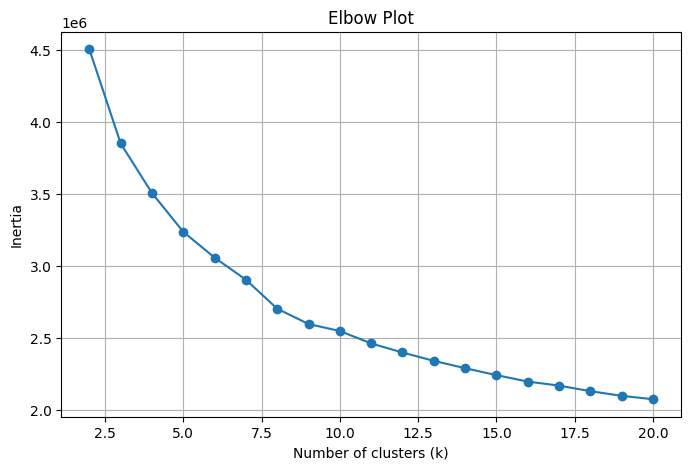

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

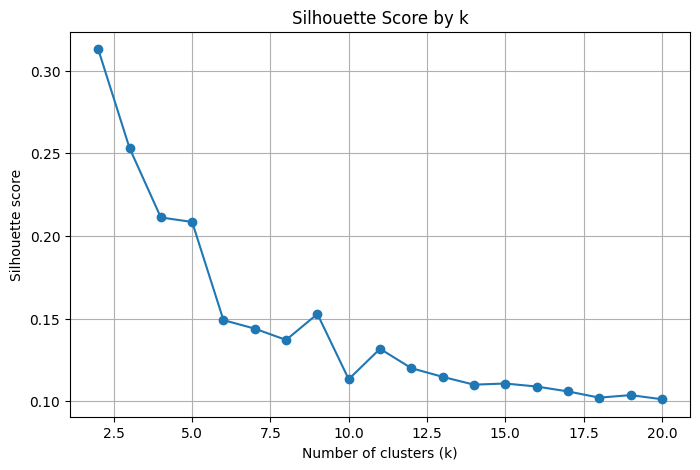

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["silhouette_sample"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by k")
plt.grid(True)
plt.show()

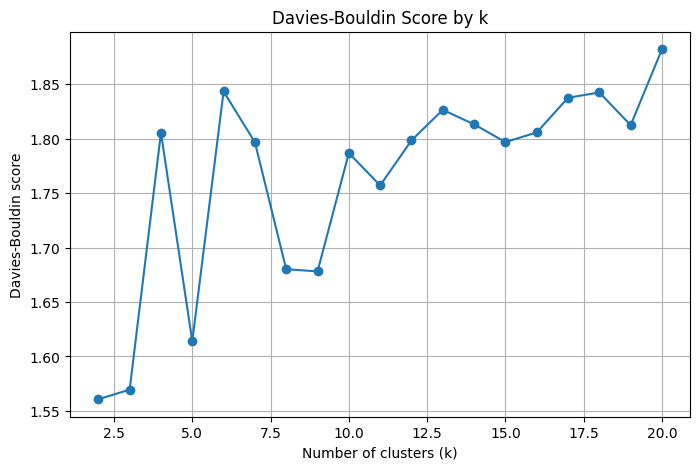

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["davies_bouldin_sample"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score")
plt.title("Davies-Bouldin Score by k")
plt.grid(True)
plt.show()

Internal validation metrics suggest the strongest broad structure is at K=2–3, but these are too coarse for strategic segmentation. The elbow curve and minimum cluster-size checks indicate K=5–6 as the most useful range. K=5 is the preferred statistical baseline; K=6 will be retained only if profile analysis demonstrates that the additional segment is substantively and geographically meaningful.

K=8, 9 or 10 may be interesting to explore, but potentially too "fine a grain".

In [27]:
k5 = 5

kmeans_5 = KMeans(
    n_clusters=k5,
    random_state=RANDOM_STATE,
    n_init=50
)

labels_5 = kmeans_5.fit_predict(X_scaled)

oa_k5 = oa[["OA21CD", "total_residents"]].copy()
oa_k5["cluster_id"] = labels_5

display(oa_k5.head())
oa_k5["cluster_id"].value_counts().sort_index()

,OA21CD,total_residents,cluster_id
0,E00000001,176,2
1,E00000003,256,2
2,E00000005,112,2
3,E00000007,144,2
4,E00000010,178,2


cluster_id
0    46507
1    44207
2    16742
3    58461
4    22963
Name: count, dtype: int64

In [28]:
k6 = 6

kmeans_6 = KMeans(
    n_clusters=k6,
    random_state=RANDOM_STATE,
    n_init=50
)

labels_6 = kmeans_6.fit_predict(X_scaled)

oa_k6 = oa[["OA21CD", "total_residents"]].copy()
oa_k6["cluster_id"] = labels_6

display(oa_k6.head())
oa_k6["cluster_id"].value_counts().sort_index()

,OA21CD,total_residents,cluster_id
0,E00000001,176,4
1,E00000003,256,4
2,E00000005,112,4
3,E00000007,144,4
4,E00000010,178,4


cluster_id
0    45178
1    56674
2    21386
3    46299
4    15817
5     3526
Name: count, dtype: int64

In [26]:
k7 = 7

kmeans_7 = KMeans(
    n_clusters=k7,
    random_state=RANDOM_STATE,
    n_init=50
)

labels_7 = kmeans_7.fit_predict(X_scaled)

oa_k7 = oa[["OA21CD", "total_residents"]].copy()
oa_k7["cluster_id"] = labels_7

display(oa_k7.head())
oa_k7["cluster_id"].value_counts().sort_index()

,OA21CD,total_residents,cluster_id
0,E00000001,176,3
1,E00000003,256,3
2,E00000005,112,3
3,E00000007,144,3
4,E00000010,178,3


cluster_id
0     3544
1    42860
2    35337
3    16223
4    40911
5    20664
6    29341
Name: count, dtype: int64

In [29]:
k8 = 8

kmeans_8 = KMeans(
    n_clusters=k8,
    random_state=RANDOM_STATE,
    n_init=50
)

labels_8 = kmeans_8.fit_predict(X_scaled)

oa_k8 = oa[["OA21CD", "total_residents"]].copy()
oa_k8["cluster_id"] = labels_8

display(oa_k8.head())
oa_k8["cluster_id"].value_counts().sort_index()

,OA21CD,total_residents,cluster_id
0,E00000001,176,6
1,E00000003,256,3
2,E00000005,112,6
3,E00000007,144,6
4,E00000010,178,6


cluster_id
0    37485
1    26976
2    19460
3    19981
4    39134
5    29755
6    12668
7     3421
Name: count, dtype: int64

In [30]:
k9 = 9

kmeans_9 = KMeans(
    n_clusters=k9,
    random_state=RANDOM_STATE,
    n_init=50
)

labels_9 = kmeans_9.fit_predict(X_scaled)

oa_k9 = oa[["OA21CD", "total_residents"]].copy()
oa_k9["cluster_id"] = labels_9

display(oa_k9.head())
oa_k9["cluster_id"].value_counts().sort_index()

,OA21CD,total_residents,cluster_id
0,E00000001,176,3
1,E00000003,256,8
2,E00000005,112,3
3,E00000007,144,3
4,E00000010,178,3


cluster_id
0    12058
1    18528
2    33390
3    12343
4    22929
5    28198
6    37905
7     3412
8    20117
Name: count, dtype: int64

In [31]:
k10 = 10

kmeans_10 = KMeans(
    n_clusters=k10,
    random_state=RANDOM_STATE,
    n_init=50
)

labels_10 = kmeans_10.fit_predict(X_scaled)

oa_k10 = oa[["OA21CD", "total_residents"]].copy()
oa_k10["cluster_id"] = labels_10

display(oa_k10.head())
oa_k10["cluster_id"].value_counts().sort_index()

,OA21CD,total_residents,cluster_id
0,E00000001,176,0
1,E00000003,256,3
2,E00000005,112,0
3,E00000007,144,0
4,E00000010,178,0


cluster_id
0    11355
1    37674
2    11999
3    19106
4    32871
5    22815
6    12906
7    28065
8     8695
9     3394
Name: count, dtype: int64

In [83]:
cluster_size = (
    oa_k10
    .groupby("cluster_id")
    .agg(
        oa_count=("OA21CD", "count"),
        population=("total_residents", "sum")
    )
    .reset_index()
)

cluster_size["oa_share"] = cluster_size["oa_count"] / cluster_size["oa_count"].sum()
cluster_size["population_share"] = cluster_size["population"] / cluster_size["population"].sum()

display(cluster_size)

,cluster_id,oa_count,population,oa_share,population_share
0,0,11355,3251847,0.060118,0.054563
1,1,37674,11859897,0.199460,0.198999
2,2,11999,2932370,0.063527,0.049203
3,3,19106,6325140,0.101154,0.106131
4,4,32871,10686288,0.174031,0.179307
5,5,22815,7279896,0.120791,0.122151
6,6,12906,5063024,0.068329,0.084953
7,7,28065,7883893,0.148586,0.132285
8,8,8695,2845239,0.046035,0.047741
9,9,3394,1470153,0.017969,0.024668


In [84]:
profile_data = X_raw.copy()
profile_data["cluster_id"] = labels_10
profile_data["total_residents"] = oa["total_residents"]

cluster_means = profile_data.groupby("cluster_id")[cluster_features].mean()
cluster_medians = profile_data.groupby("cluster_id")[cluster_features].median()

overall_means = profile_data[cluster_features].mean()
overall_stds = profile_data[cluster_features].std()

cluster_z = (cluster_means - overall_means) / overall_stds

display(cluster_means)
display(cluster_z)

,age_15_24_pct,age_25_34_pct,age_50_64_pct,age_65_plus_pct,uk_born_pct,non_uk_born_pct,resident_10_plus_years_pct,resident_less_5_years_pct,white_british_pct,white_other_pct,...,full_time_student_pct,retired_pct,long_term_sick_disabled_pct,no_qualifications_pct,level_1_2_pct,apprenticeship_pct,level_4_plus_pct,one_person_household_pct,married_couple_family_pct,lone_parent_family_pct
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,0.115982,0.278055,0.137087,0.087028,0.565163,0.434837,0.190658,0.149838,0.428586,0.202256,...,0.087921,0.086236,0.026240,0.099643,0.122453,0.024316,0.602769,0.383552,0.216009,0.077652
1,0.104006,0.132814,0.213702,0.184056,0.922521,0.077479,0.049013,0.014778,0.888146,0.033943,...,0.053210,0.214984,0.040186,0.187873,0.269776,0.066183,0.262862,0.284552,0.316319,0.116324
2,0.087672,0.123364,0.211162,0.279071,0.888118,0.111882,0.064742,0.026504,0.852996,0.046457,...,0.043675,0.297860,0.099591,0.294051,0.243208,0.063660,0.222457,0.530572,0.156571,0.100699
3,0.102648,0.175095,0.167551,0.117473,0.794224,0.205776,0.123380,0.045654,0.688865,0.088476,...,0.067930,0.136274,0.023517,0.108444,0.198296,0.037793,0.465726,0.269220,0.344392,0.102580
4,0.095240,0.083308,0.239273,0.235280,0.914073,0.085927,0.063644,0.012401,0.876800,0.030847,...,0.056360,0.277293,0.016123,0.110935,0.213736,0.048558,0.438288,0.217939,0.428552,0.063599
5,0.125792,0.143757,0.180282,0.131807,0.885559,0.114441,0.065274,0.024621,0.821120,0.051224,...,0.072216,0.155710,0.090037,0.276973,0.292541,0.056718,0.188986,0.301241,0.233510,0.211889
6,0.139083,0.155985,0.158497,0.104756,0.570174,0.429826,0.248809,0.103586,0.269719,0.110953,...,0.109927,0.118653,0.043477,0.250628,0.231264,0.040439,0.299769,0.225323,0.338152,0.145589
7,0.074342,0.078657,0.228244,0.357799,0.948361,0.051639,0.038345,0.007226,0.938828,0.018326,...,0.037107,0.397437,0.028703,0.196717,0.233450,0.076697,0.298411,0.309639,0.307416,0.062179
8,0.137789,0.173930,0.167724,0.097147,0.587119,0.412881,0.258005,0.085445,0.305354,0.117215,...,0.114851,0.102670,0.074735,0.234693,0.217571,0.038362,0.336661,0.361510,0.202672,0.201399


,age_15_24_pct,age_25_34_pct,age_50_64_pct,age_65_plus_pct,uk_born_pct,non_uk_born_pct,resident_10_plus_years_pct,resident_less_5_years_pct,white_british_pct,white_other_pct,...,full_time_student_pct,retired_pct,long_term_sick_disabled_pct,no_qualifications_pct,level_1_2_pct,apprenticeship_pct,level_4_plus_pct,one_person_household_pct,married_couple_family_pct,lone_parent_family_pct
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,0.137969,2.157183,-1.124322,-0.975189,-1.805444,1.805444,1.160031,2.071022,-1.367745,2.201332,...,0.330732,-1.123524,-0.454731,-0.974007,-1.773698,-1.213597,1.893054,0.722559,-0.807743,-0.491378
1,-0.096372,-0.017190,0.272799,-0.094068,0.539498,-0.539498,-0.523471,-0.431689,0.522254,-0.402022,...,-0.283008,-0.049818,-0.078994,0.036994,0.614809,0.490298,-0.519118,-0.127017,0.105119,0.078786
2,-0.415996,-0.158656,0.226478,0.768766,0.313752,-0.313752,-0.336521,-0.214397,0.377694,-0.208469,...,-0.451594,0.641340,1.521519,1.253649,0.184077,0.387624,-0.805849,1.984225,-1.348653,-0.151581
3,-0.122942,0.615795,-0.568783,-0.698713,-0.302373,0.302373,0.360412,0.140458,-0.297315,0.441451,...,-0.022738,-0.706221,-0.528073,-0.873158,-0.544081,-0.665117,0.920517,-0.258591,0.360588,-0.123850
4,-0.267899,-0.758331,0.739089,0.371096,0.484063,-0.484063,-0.349572,-0.475741,0.475594,-0.449911,...,-0.227317,0.469822,-0.727294,-0.844610,-0.293755,-0.227009,0.725803,-0.698657,1.126471,-0.698570
5,0.329937,0.146642,-0.336637,-0.568542,0.296963,-0.296963,-0.330197,-0.249291,0.246600,-0.134740,...,0.053044,-0.544136,1.264135,1.057961,0.983894,0.105082,-1.043380,0.016202,-0.648477,1.487768
6,0.590013,0.329706,-0.733899,-0.814201,-1.772565,1.772565,1.851171,1.213958,-2.021110,0.789111,...,0.719820,-0.853180,0.009687,0.756080,-0.009574,-0.557411,-0.257202,-0.635297,0.303803,0.510261
7,-0.676822,-0.827960,0.537968,1.483700,0.709057,-0.709057,-0.650261,-0.571623,0.730691,-0.643581,...,-0.567737,1.471772,-0.388373,0.138328,0.025871,0.918200,-0.266839,0.088274,0.024097,-0.719514
8,0.564681,0.598355,-0.565640,-0.883292,-1.661371,1.661371,1.960477,0.877797,-1.874557,0.885975,...,0.806874,-0.986468,0.851841,0.573483,-0.231578,-0.641964,0.004600,0.533404,-0.929109,1.333101


In [85]:
cluster_size.to_csv(MODEL_DIR / "k10_cluster_sizes_v1.csv", index=False)
cluster_means.to_csv(MODEL_DIR / "k10_cluster_feature_means_v1.csv")
cluster_medians.to_csv(MODEL_DIR / "k10_cluster_feature_medians_v1.csv")
cluster_z.to_csv(MODEL_DIR / "k10_cluster_feature_zscores_v1.csv")

In [86]:
def top_bottom_features(cluster_zscores, n=8):
    rows = []

    for cluster_id in cluster_zscores.index:
        z = cluster_zscores.loc[cluster_id].sort_values(ascending=False)

        for feature, value in z.head(n).items():
            rows.append({
                "cluster_id": cluster_id,
                "direction": "high",
                "feature": feature,
                "z_score": value
            })

        for feature, value in z.tail(n).items():
            rows.append({
                "cluster_id": cluster_id,
                "direction": "low",
                "feature": feature,
                "z_score": value
            })

    return pd.DataFrame(rows)

cluster_defining_features = top_bottom_features(cluster_z, n=10)

display(cluster_defining_features)
cluster_defining_features.to_csv(MODEL_DIR / "k10_cluster_defining_features_v1.csv", index=False)

,cluster_id,direction,feature,z_score
0,0,high,white_other_pct,2.201332
1,0,high,age_25_34_pct,2.157183
2,0,high,flat_type_pct,2.108720
3,0,high,resident_less_5_years_pct,2.071022
4,0,high,level_4_plus_pct,1.893054
...,...,...,...,...
195,9,low,retired_pct,-1.271001
196,9,low,owned_pct,-1.292031
197,9,low,apprenticeship_pct,-1.344538
198,9,low,level_1_2_pct,-1.831465


In [87]:
feature_labels = {
    "age_15_24_pct": "Age 15–24",
    "age_25_34_pct": "Age 25–34",
    "age_50_64_pct": "Age 50–64",
    "age_65_plus_pct": "Age 65+",

    "uk_born_pct": "UK-born",
    "non_uk_born_pct": "Non-UK-born",
    "resident_10_plus_years_pct": "Resident 10+ years",
    "resident_less_5_years_pct": "Resident under 5 years",

    "white_british_pct": "White British",
    "white_other_pct": "Other White",
    "non_white_pct": "Non-white ethnic group",

    "owned_pct": "Owner-occupied",
    "owns_outright_pct": "Owned outright",
    "social_rented_pct": "Social rented",
    "private_rented_pct": "Private rented",
    "house_type_pct": "House / bungalow",
    "flat_type_pct": "Flat / apartment",

    "managerial_professional_pct": "Managerial / professional occupations",
    "skilled_traditional_pct": "Skilled trades / process operatives",
    "routine_service_elementary_pct": "Routine / service / elementary occupations",

    "employed_pct": "Employed",
    "unemployed_pct": "Unemployed",
    "full_time_student_pct": "Full-time student",
    "retired_pct": "Retired",
    "long_term_sick_disabled_pct": "Long-term sick / disabled",

    "no_qualifications_pct": "No qualifications",
    "level_1_2_pct": "Level 1–2 qualifications",
    "apprenticeship_pct": "Apprenticeship",
    "level_4_plus_pct": "Level 4+ qualifications",

    "one_person_household_pct": "One-person households",
    "married_couple_family_pct": "Married-couple families",
    "lone_parent_family_pct": "Lone-parent families",
}

cluster_defining_features["feature_label"] = (
    cluster_defining_features["feature"].map(feature_labels)
    .fillna(cluster_defining_features["feature"])
)

display(cluster_defining_features)

,cluster_id,direction,feature,z_score,feature_label
0,0,high,white_other_pct,2.201332,Other White
1,0,high,age_25_34_pct,2.157183,Age 25–34
2,0,high,flat_type_pct,2.108720,Flat / apartment
3,0,high,resident_less_5_years_pct,2.071022,Resident under 5 years
4,0,high,level_4_plus_pct,1.893054,Level 4+ qualifications
...,...,...,...,...,...
195,9,low,retired_pct,-1.271001,Retired
196,9,low,owned_pct,-1.292031,Owner-occupied
197,9,low,apprenticeship_pct,-1.344538,Apprenticeship
198,9,low,level_1_2_pct,-1.831465,Level 1–2 qualifications


In [88]:
profile_summaries = []

for cluster_id in sorted(cluster_defining_features["cluster_id"].unique()):
    highs = (
        cluster_defining_features[
            (cluster_defining_features["cluster_id"] == cluster_id)
            & (cluster_defining_features["direction"] == "high")
        ]
        .sort_values("z_score", ascending=False)
        .head(6)["feature_label"]
        .tolist()
    )

    lows = (
        cluster_defining_features[
            (cluster_defining_features["cluster_id"] == cluster_id)
            & (cluster_defining_features["direction"] == "low")
        ]
        .sort_values("z_score", ascending=True)
        .head(6)["feature_label"]
        .tolist()
    )

    profile_summaries.append({
        "cluster_id": cluster_id,
        "high_features": "; ".join(highs),
        "low_features": "; ".join(lows),
    })

profile_summaries = pd.DataFrame(profile_summaries)

profile_summaries = profile_summaries.merge(cluster_size, on="cluster_id", how="left")

display(profile_summaries)
profile_summaries.to_csv(MODEL_DIR / "k10_cluster_profile_summaries_v1.csv", index=False)

,cluster_id,high_features,low_features,oa_count,population,oa_share,population_share
0,0,Other White; Age 25–34; Flat / apartment; Resi...,House / bungalow; UK-born; Level 1–2 qualifica...,11355,3251847,0.060118,0.054563
1,1,Level 1–2 qualifications; UK-born; Skilled tra...,Non-UK-born; Resident 10+ years; Level 4+ qual...,37674,11859897,0.199460,0.198999
2,2,One-person households; Long-term sick / disabl...,Married-couple families; Employed; Owner-occup...,11999,2932370,0.063527,0.049203
3,3,Employed; Level 4+ qualifications; Managerial ...,No qualifications; Skilled trades / process op...,19106,6325140,0.101154,0.106131
4,4,Married-couple families; Owner-occupied; Manag...,Routine / service / elementary occupations; No...,32871,10686288,0.174031,0.179307
5,5,Lone-parent families; Routine / service / elem...,Managerial / professional occupations; Level 4...,22815,7279896,0.120791,0.122151
6,6,Non-white ethnic group; Resident 10+ years; No...,White British; UK-born; Retired; Age 65+; Age ...,12906,5063024,0.068329,0.084953
7,7,Age 65+; Retired; Owned outright; Apprenticesh...,Employed; Age 25–34; Unemployed; Lone-parent f...,28065,7883893,0.148586,0.132285
8,8,Resident 10+ years; Non-white ethnic group; Fl...,House / bungalow; White British; Owner-occupie...,8695,2845239,0.046035,0.047741
9,9,Full-time student; Age 15–24; Private rented; ...,Age 50–64; Level 1–2 qualifications; Apprentic...,3394,1470153,0.017969,0.024668


In [89]:
age_profile_cols = [
    "age_0_14_count",
    "age_15_24_count",
    "age_25_34_count",
    "age_35_49_count",
    "age_50_64_count",
    "age_65_plus_count",
]

full_features = pd.read_csv(OUT_DIR / "oa_derived_features_full_v1.csv", low_memory=False)

age_profile = full_features[["OA21CD"] + age_profile_cols].merge(
    oa_k10[["OA21CD", "cluster_id"]],
    on="OA21CD",
    how="left"
)

cluster_age_counts = age_profile.groupby("cluster_id")[age_profile_cols].sum()

cluster_age_shares = cluster_age_counts.div(cluster_age_counts.sum(axis=1), axis=0)

display(cluster_age_shares)
cluster_age_shares.to_csv(MODEL_DIR / "k10_cluster_age_band_shares_v1.csv")

,age_0_14_count,age_15_24_count,age_25_34_count,age_35_49_count,age_50_64_count,age_65_plus_count
cluster_id,,,,,,
0,0.136634,0.116062,0.287021,0.241200,0.134629,0.084455
1,0.175420,0.104612,0.133387,0.193450,0.211525,0.181605
2,0.132297,0.089160,0.125293,0.167526,0.209465,0.276259
3,0.204311,0.104135,0.174495,0.237526,0.164767,0.114765
4,0.162500,0.095898,0.083817,0.187789,0.237916,0.232081
5,0.228243,0.126925,0.144148,0.193778,0.177968,0.128938
6,0.220721,0.140983,0.155614,0.222515,0.156794,0.103373
7,0.117138,0.075063,0.078958,0.144620,0.228047,0.356173
8,0.210516,0.140567,0.173508,0.217620,0.164643,0.093145


In [90]:
age_midpoints = {
    "age_0_14_count": 7,
    "age_15_24_count": 19.5,
    "age_25_34_count": 29.5,
    "age_35_49_count": 42,
    "age_50_64_count": 57,
    "age_65_plus_count": 75,
}

cluster_age_counts["approx_mean_age"] = sum(
    cluster_age_counts[col] * midpoint
    for col, midpoint in age_midpoints.items()
) / cluster_age_counts[age_profile_cols].sum(axis=1)

display(cluster_age_counts[["approx_mean_age"]])

,approx_mean_age
cluster_id,
0,35.825097
1,41.005047
2,46.055873
3,36.583657
4,44.334488
5,36.278297
6,34.920697
7,50.398694
8,34.843752


In [91]:
def median_age_band(row):
    total = row.sum()
    cumulative = row.cumsum()
    midpoint = total / 2

    for col in row.index:
        if cumulative[col] >= midpoint:
            return col.replace("age_", "").replace("_count", "").replace("_", " ")

    return np.nan

cluster_age_counts["approx_median_age_band"] = cluster_age_counts[age_profile_cols].apply(
    median_age_band,
    axis=1
)

display(cluster_age_counts[["approx_mean_age", "approx_median_age_band"]])

,approx_mean_age,approx_median_age_band
cluster_id,,
0,35.825097,25 34
1,41.005047,35 49
2,46.055873,35 49
3,36.583657,35 49
4,44.334488,35 49
5,36.278297,35 49
6,34.920697,25 34
7,50.398694,50 64
8,34.843752,25 34


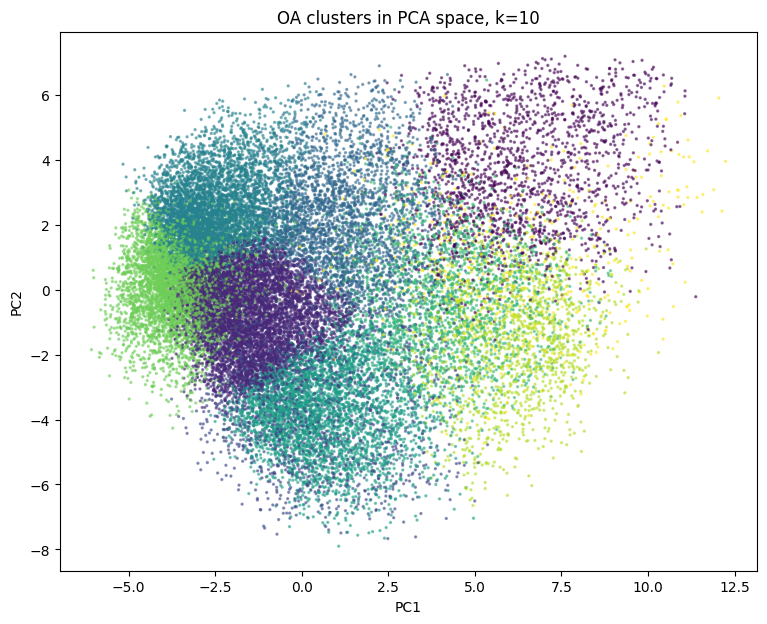

Explained variance: [0.35464019 0.21373472]


In [92]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster_id": labels_10
})

# Plot a sample, not all 188k points
plot_df = pca_df.sample(30000, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 7))
plt.scatter(
    plot_df["pc1"],
    plot_df["pc2"],
    c=plot_df["cluster_id"],
    s=2,
    alpha=0.5
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("OA clusters in PCA space, k=10")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)